In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score




In [2]:
#load datasets 

data = fetch_california_housing()
X= pd.DataFrame(data.data,columns=data.feature_names)
y= pd.Series(data.target)

In [3]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [4]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Length: 20640, dtype: float64

In [5]:
# using train test split for splitting the data 

X_train , X_test , y_train , y_test = train_test_split(X,y,random_state=1, test_size= 0.20)



In [ ]:
#feature scaling 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)          #calculating mean and std 
X_test_sclaed = scaler.transform(X_test )               # centered around 0  -3 to +3 

In [33]:
X_test_sclaed

array([[-0.33102858,  0.82598181, -0.35885058, ..., -0.11362606,
        -0.73569355,  0.60487084],
       [-1.0032899 ,  0.66707086, -0.173141  , ..., -0.04185389,
         0.53710549, -0.10247067],
       [ 0.0724551 ,  1.38217013, -0.36761594, ...,  0.05892484,
         0.98164928, -1.41752814],
       ...,
       [ 0.61952652, -0.20693936, -0.16877334, ...,  0.04929666,
         0.92081697, -1.39262175],
       [ 0.52806599,  1.06434823, -0.03563168, ..., -0.00503065,
        -0.72165533,  0.73438408],
       [-0.61894421,  1.85890297,  0.11482041, ..., -0.01755593,
        -0.76844941,  1.09303611]])

In [13]:
print("Sclaed value",X_train_scaled)
print("non_scaled_value /n",X_train)

Sclaed value [[-0.36232605  1.85890297 -0.16877334 ...  0.00190139  0.97229046
  -1.42250942]
 [-0.14102329  1.06434823 -0.20665523 ...  0.00945496  1.08459626
  -1.38265919]
 [-0.66144956 -1.0014941   1.10658361 ...  0.02055372  1.06119922
  -0.8297373 ]
 ...
 [-1.45044201  1.06434823 -0.21055978 ... -0.03879603 -0.79652586
   0.65468363]
 [-0.65764311 -1.47822694 -0.17198179 ... -0.02771272 -0.89011402
   1.20262424]
 [-0.83136525  0.50815991 -0.31396782 ... -0.04378624  1.00972573
  -1.30794002]]
non_scaled_value /n        MedInc  HouseAge  AveRooms  ...  AveOccup  Latitude  Longitude
15961  3.1908      52.0  5.000000  ...  3.117021     37.71    -122.43
1771   3.6094      42.0  4.900990  ...  3.204620     37.95    -122.35
16414  2.6250      16.0  8.333333  ...  3.333333     37.90    -121.24
5056   1.5143      34.0  3.805981  ...  2.580598     34.02    -118.35
8589   7.3356      38.0  5.894904  ...  2.388535     33.89    -118.39
...       ...       ...       ...  ...       ...       

In [14]:
#training the model 
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [16]:
#predictions

y_pred = ridge.predict(X_test_sclaed)
print(y_pred)

[2.12559808 0.94019605 2.70860514 ... 2.94563711 2.63883818 1.47032221]


In [19]:
#evulatiopn 

rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2= r2_score(y_test,y_pred)

print("rmse",rmse)
print("r2",r2)

rmse 0.7274123128070602
r2 0.5966056518420819


In [20]:
alphas = [0.01,0.1,1,5,10,100]

for a in alphas:
    model = Ridge(alpha= a)
    model.fit(X_train_scaled,y_train)
    pred = model.predict(X_test_sclaed)

    rmse = np.sqrt(mean_squared_error(y_test,pred))
    print(f"Alpha:{a},RMSE:{rmse}")

Alpha:0.01,RMSE:0.7274201797271412
Alpha:0.1,RMSE:0.7274194586616175
Alpha:1,RMSE:0.7274123128070602
Alpha:5,RMSE:0.7273819668613432
Alpha:10,RMSE:0.7273472253212755
Alpha:100,RMSE:0.7272380103046721


In [27]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
15961,3.1908,52.0,5.000000,1.014184,879.0,3.117021,37.71,-122.43
1771,3.6094,42.0,4.900990,0.957096,971.0,3.204620,37.95,-122.35
16414,2.6250,16.0,8.333333,1.666667,20.0,3.333333,37.90,-121.24
5056,1.5143,34.0,3.805981,1.149526,3538.0,2.580598,34.02,-118.35
8589,7.3356,38.0,5.894904,1.057325,750.0,2.388535,33.89,-118.39
...,...,...,...,...,...,...,...,...
10955,1.7823,17.0,4.055046,1.087156,1079.0,2.474771,33.76,-117.88
17289,8.5608,42.0,6.788462,1.011538,753.0,2.896154,34.42,-119.63
5192,1.1326,42.0,4.890785,1.006826,775.0,2.645051,33.93,-118.26
12172,2.6322,10.0,4.991614,0.951782,1323.0,2.773585,33.73,-117.16


In [25]:
X_train_scaled

array([[-0.36232605,  1.85890297, -0.16877334, ...,  0.00190139,
         0.97229046, -1.42250942],
       [-0.14102329,  1.06434823, -0.20665523, ...,  0.00945496,
         1.08459626, -1.38265919],
       [-0.66144956, -1.0014941 ,  1.10658361, ...,  0.02055372,
         1.06119922, -0.8297373 ],
       ...,
       [-1.45044201,  1.06434823, -0.21055978, ..., -0.03879603,
        -0.79652586,  0.65468363],
       [-0.65764311, -1.47822694, -0.17198179, ..., -0.02771272,
        -0.89011402,  1.20262424],
       [-0.83136525,  0.50815991, -0.31396782, ..., -0.04378624,
         1.00972573, -1.30794002]])

In [30]:
X_test.shape

(4128, 8)

In [32]:
X_test_sclaed

array([[-0.33102858,  0.82598181, -0.35885058, ..., -0.11362606,
        -0.73569355,  0.60487084],
       [-1.0032899 ,  0.66707086, -0.173141  , ..., -0.04185389,
         0.53710549, -0.10247067],
       [ 0.0724551 ,  1.38217013, -0.36761594, ...,  0.05892484,
         0.98164928, -1.41752814],
       ...,
       [ 0.61952652, -0.20693936, -0.16877334, ...,  0.04929666,
         0.92081697, -1.39262175],
       [ 0.52806599,  1.06434823, -0.03563168, ..., -0.00503065,
        -0.72165533,  0.73438408],
       [-0.61894421,  1.85890297,  0.11482041, ..., -0.01755593,
        -0.76844941,  1.09303611]])

In [34]:
coefficients = pd.DataFrame(
    {
        "Feature":X.columns,
        "Coefficient":ridge.coef_
    }
)
print(coefficients.sort_values(by='Coefficient',ascending=False))

      Feature  Coefficient
0      MedInc     0.829522
3   AveBedrms     0.320381
1    HouseAge     0.122004
4  Population    -0.004102
5    AveOccup    -0.039988
2    AveRooms    -0.273477
7   Longitude    -0.883715
6    Latitude    -0.909504


In [41]:
#now lets use linear Reg model 
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

liner_model =lr.fit(X_train_scaled,y_train) # inputs, outputs
lr_pred = lr.predict(X_test_sclaed)

print("Linear RMSE",np.sqrt(mean_squared_error(y_test,lr_pred)))

Linear RMSE 0.727420259918385


In [ ]:
#now lets see if coef is shrinking or not 

for a in [0.01,1,100]:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled,y_train)
    print(f"alpha:{a}")
    print(model.coef_)

alpha:0.01
[ 0.82955763  0.12192096 -0.27366011  0.32061763 -0.00413152 -0.03998336
 -0.91028679 -0.88450615]
alpha:1
[ 0.82952178  0.12200436 -0.27347719  0.32038111 -0.00410179 -0.03998849
 -0.90950357 -0.88371487]
alpha:100
[ 0.82516805  0.12946978 -0.25508579  0.29726208 -0.00143294 -0.04040326
 -0.83841651 -0.8117984 ]


In [38]:
print("coefficients",lr.coef_)
print("intercept",lr.intercept_)

coefficients [ 0.82955799  0.12192011 -0.27366196  0.32062002 -0.00413182 -0.03998331
 -0.91029471 -0.88451415]
intercept 2.077350641957363


In [43]:
sample = X_test.iloc[0]

In [44]:
sample

MedInc           3.250000
HouseAge        39.000000
AveRooms         4.503205
AveBedrms        1.073718
Population    1109.000000
AveOccup         1.777244
Latitude        34.060000
Longitude     -118.360000
Name: 4712, dtype: float64

In [46]:
sample_scaled = scaler.transform([sample])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [47]:
sample_scaled

array([[-0.33102858,  0.82598181, -0.35885058, -0.0510288 , -0.28143698,
        -0.11362606, -0.73569355,  0.60487084]])

In [48]:
import numpy as np

manual_pred = np.dot(sample_scaled,lr.coef_) + lr.intercept_

In [49]:
manual_pred



array([2.12567705])

In [50]:
model_pred = lr.predict(sample_scaled)
model_pred

array([2.12567705])

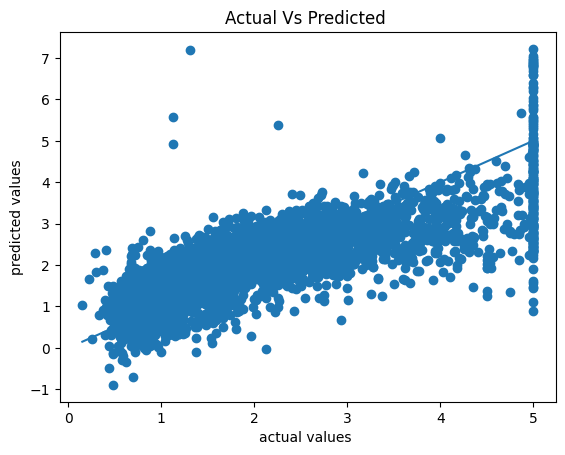

In [51]:
import matplotlib.pyplot as plt

plt.scatter(y_test,y_pred)
plt.xlabel("actual values ")
plt.ylabel("predicted values")
plt.title("Actual Vs Predicted ")


plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()])

plt.show()

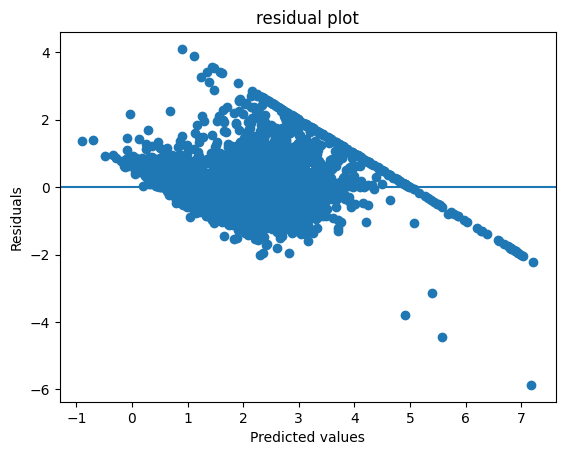

In [53]:
residuals = y_test - y_pred
plt.scatter(y_pred,residuals)
plt.axhline(y=0)
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("residual plot")
plt.show()

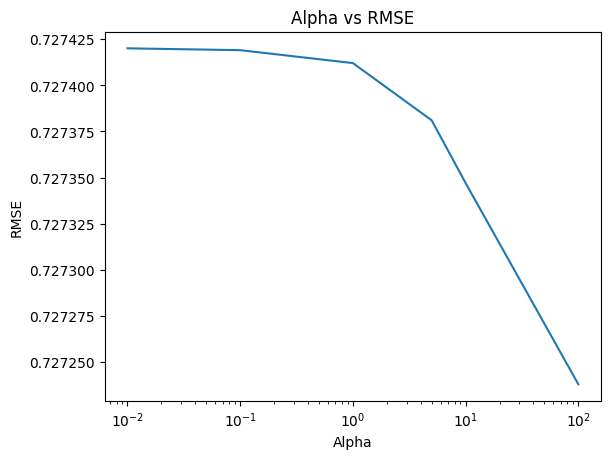

In [54]:
alphas = [0.01, 0.1, 1, 5, 10, 100]
rmses = [0.727420, 0.727419, 0.727412, 0.727381, 0.727347, 0.727238]

plt.plot(alphas, rmses)
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("Alpha vs RMSE")
plt.show()

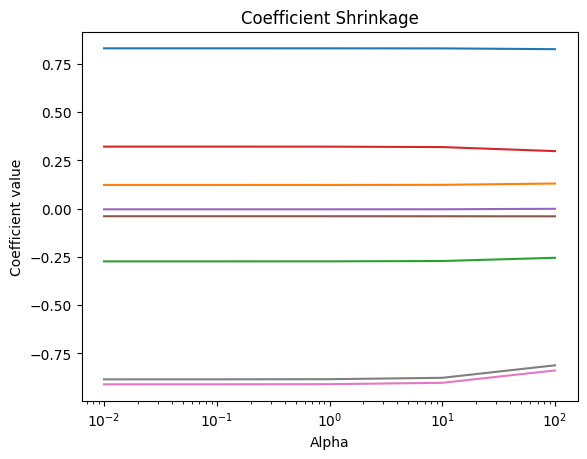

In [55]:
import numpy as np

alphas = [0.01, 0.1, 1, 10, 100]
coefs = []

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    coefs.append(model.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Coefficient value")
plt.title("Coefficient Shrinkage")
plt.show()

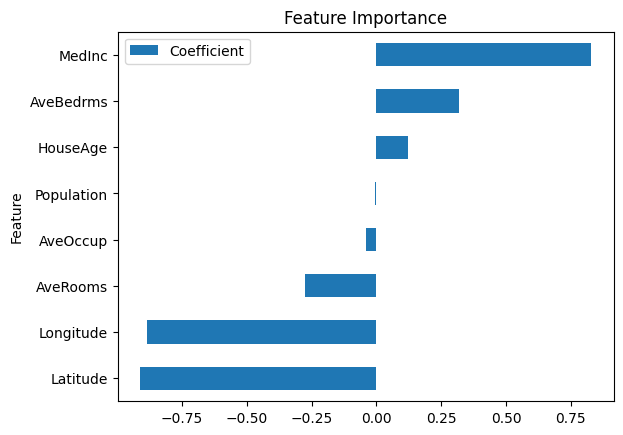

In [56]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coef_df.sort_values(by="Coefficient").plot(
    kind="barh", x="Feature", y="Coefficient"
)

plt.title("Feature Importance")
plt.show()

In [57]:
## now lets use Lasso L1

from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled,y_train)

#preditions

y_pred_lasso= lasso.predict(X_test_sclaed)

rmse_lasso = np.sqrt(mean_squared_error(y_test,y_pred_lasso))

print("Lasso Rmse",rmse_lasso)

Lasso Rmse 1.1461341688651658


In [58]:
#now tunning alphas 

alphas =[0.001,0.01,0.1,1,10]

for a in alphas:
    model = Lasso(alpha=a)
    model.fit(X_train_scaled,y_train)
    pred = model.predict(X_test_sclaed)

    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    print(f"Alpha:{a},RMSE:{rmse})")

Alpha:0.001,RMSE:0.7274123128070602)
Alpha:0.01,RMSE:0.7274123128070602)
Alpha:0.1,RMSE:0.7274123128070602)
Alpha:1,RMSE:0.7274123128070602)
Alpha:10,RMSE:0.7274123128070602)


In [60]:
for a in [0.001,0.1,1]:
    model= Lasso(alpha=a)
    model.fit(X_train_scaled,y_train)

    print(f"\nAlpha:{a}")
    print(model.coef_)


Alpha:0.001
[ 0.82427787  0.12286936 -0.25903017  0.30596875 -0.00275208 -0.03906354
 -0.89943919 -0.87299682]

Alpha:0.1
[ 0.7084659   0.10985092 -0.          0.         -0.         -0.
 -0.00776985 -0.        ]

Alpha:1
[ 0.  0.  0. -0. -0. -0. -0. -0.]


<Axes: ylabel='Feature'>

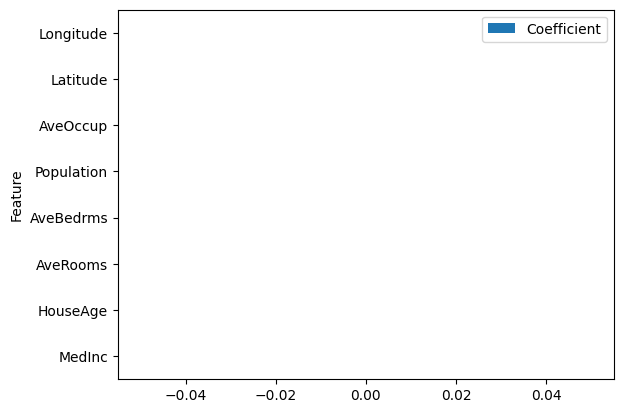

In [61]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso.coef_
})

coef_df.sort_values(by="Coefficient").plot(
    kind="barh", x="Feature", y="Coefficient"
)

In [62]:
from sklearn.linear_model import ElasticNet

model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(X_train_scaled,y_train)

pred = model.predict(X_test_sclaed)

rmse = np.sqrt(mean_squared_error(y_test,pred))
print("Rmse:",rmse)

Rmse: 0.7876779031912757


In [63]:
for l1 in [0.2,0.5,0.8]:

    model = ElasticNet(alpha=0.1, l1_ratio=l1)
    model.fit(X_train_scaled,y_train)

    print(f"\nl1_ratio:{l1}")
    print(model.coef_)


l1_ratio:0.2
[ 0.70704143  0.15003193 -0.          0.01135409  0.         -0.02007128
 -0.33971307 -0.30045059]

l1_ratio:0.5
[ 0.71138498  0.14034576 -0.          0.          0.         -0.
 -0.17471564 -0.13582601]

l1_ratio:0.8
[ 0.71497365  0.12826894 -0.          0.          0.         -0.
 -0.02690502 -0.        ]


In [64]:
for l1 in [0.2,0.5,0.8]:
    model = ElasticNet(alpha=l1,l1_ratio=l1)
    model.fit(X_train_scaled,y_train)

    pred = model.predict(X_test_sclaed)

    rmse = np.sqrt(mean_squared_error(y_test,pred))

    print(f"l1_ratio:{l1},RMSE:{rmse}")

l1_ratio:0.2,RMSE:0.7973157517543142
l1_ratio:0.5,RMSE:0.8996824203517687
l1_ratio:0.8,RMSE:1.0566233934406053


In [65]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    Ridge(alpha=100),
    X_train_scaled,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv= 5
)

print(scores)
print("Mean RMSE:",-scores.mean())

[-0.722812   -0.72490593 -0.72943884 -0.71085532 -0.74686745]
Mean RMSE: 0.7269759062791229
